### 연평균 성장률 (Compoind Annual Growth Rates, CAGR)

In [76]:
def getCAGR(first, last, years):
    return (last/first)**(1/years)-1

연평균 성장률 구하기

In [77]:
cagr = getCAGR(65300, 2669000, 20)
print(f"SEC CAGR : {cagr*100:.2f}%")

SEC CAGR : 20.38%


Python 에서 제공하는 키워드 알아보기

In [78]:
import keyword
print(keyword.kwlist)

['False', 'None', 'True', 'and', 'as', 'assert', 'async', 'await', 'break', 'class', 'continue', 'def', 'del', 'elif', 'else', 'except', 'finally', 'for', 'from', 'global', 'if', 'import', 'in', 'is', 'lambda', 'nonlocal', 'not', 'or', 'pass', 'raise', 'return', 'try', 'while', 'with', 'yield']


In [79]:
print(keyword.__file__)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/keyword.py


In [80]:
import calendar
print(calendar.month(2020, 1))

    January 2020
Mo Tu We Th Fr Sa Su
       1  2  3  4  5
 6  7  8  9 10 11 12
13 14 15 16 17 18 19
20 21 22 23 24 25 26
27 28 29 30 31



In [81]:
from calendar import month
print(month(2020, 1))

    January 2020
Mo Tu We Th Fr Sa Su
       1  2  3  4  5
 6  7  8  9 10 11 12
13 14 15 16 17 18 19
20 21 22 23 24 25 26
27 28 29 30 31



Pandas 시리즈 생성

In [82]:
import pandas as pd
s = pd.Series([0.0, 3.6, 2.0, 5.8, 4.2, 8.8])

인덱스 변경 [0, 1, 2, 3, 4, 5] -> [0.0, 1.2, 1.8, 3.0, 3.6, 4.8]

In [83]:
s.index = pd.Index([0.0, 1.2, 1.8, 3.0, 3.6, 4.8])
s.index.name = 'MY_IDX'

시리즈 이름 설정

In [84]:
s.name = 'MY_SERIES'

데이터 추가 (pandas 2.0 이상부터 append 가 삭제됨. concat 으로 해야함)

In [85]:
s[5.9] = 5.5
ser = pd.Series([6.7, 4.2], index=[6.8, 8.0])
s = pd.concat([s, ser])

데이터 삭제

In [86]:
print(s.drop(8.0))

0.0    0.0
1.2    3.6
1.8    2.0
3.0    5.8
3.6    4.2
4.8    8.8
5.9    5.5
6.8    6.7
dtype: float64


시리즈 정보 확인

In [87]:
s.describe()

count    9.000000
mean     4.533333
std      2.586020
min      0.000000
25%      3.600000
50%      4.200000
75%      5.800000
max      8.800000
dtype: float64

matplotlip 으로 시각화 하기

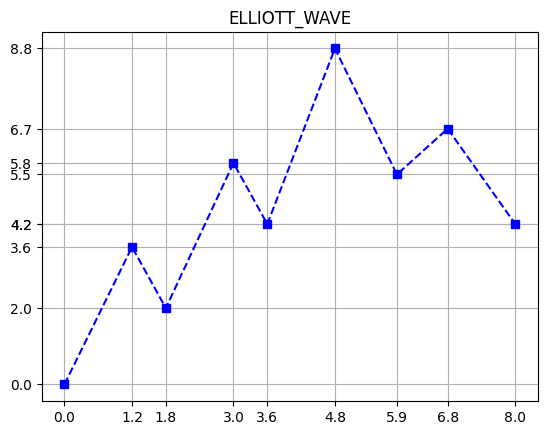

In [88]:
import matplotlib.pyplot as plt
plt.title("ELLIOTT_WAVE")
plt.plot(s, 'bs--') # 시리즈를 푸른 사각형과 점선 형태로 출력 (bs--)
plt.xticks(s.index)
plt.yticks(s.values)
plt.grid(True)
plt.show()

야후 파이낸스를 이용하여 주식 비교
삼성전자, 마이크로소프트 주식 정보 가져오기.
책과 내용 많이 다름. https://pypi.org/project/yfinance/ 참조.

In [89]:
from pandas_datareader import data as pdr
import yfinance as yf

sec = yf.Ticker("005930.KS") # 삼성의 symbol. yfinance 웹 페이지에서 확인할 수 있다.
msft = yf.Ticker("MSFT")

sec_data = sec.history(start="2022-05-04")
msft_data = msft.history(start="2022-05-04")

주식 비교 그래프 출력

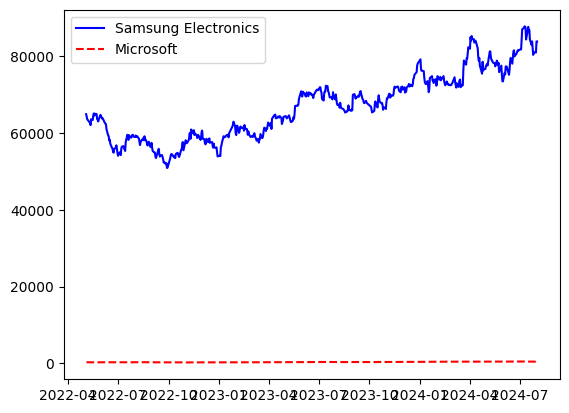

In [90]:
import matplotlib.pyplot as plt
plt.plot(sec_data.index, sec_data.Close, 'b', label='Samsung Electronics')
plt.plot(msft_data.index, msft_data.Close, 'r--', label='Microsoft')
plt.legend(loc='best')
plt.show()

일간 변동률로 주가 비교하기

In [91]:
type(sec_data['Close']) # 자료형 부터 확인 pandas.core.series.Series

pandas.core.series.Series

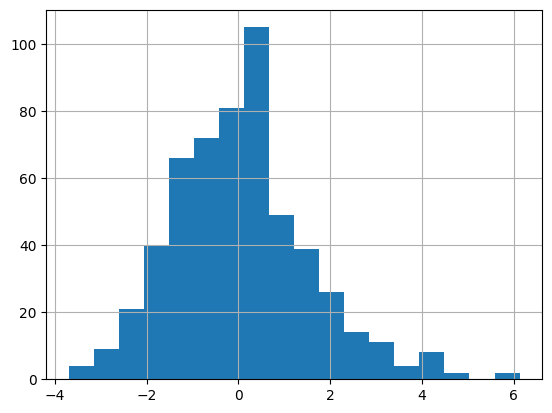

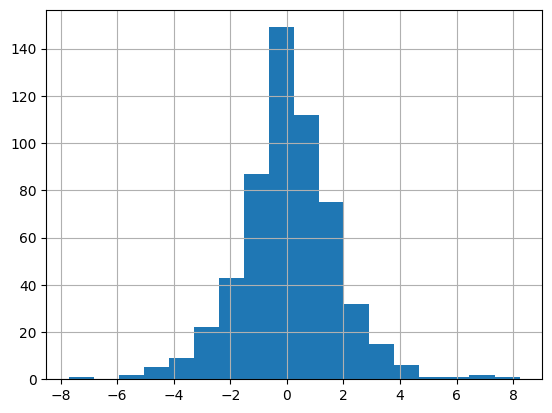

In [92]:
sec_dpc = (sec_data['Close'] / sec_data['Close'].shift(1) - 1) * 100
msft_dpc = (msft_data['Close'] / msft_data['Close'].shift(1) - 1) * 100

sec_dpc.iloc[0]=0
msft_dpc.iloc[0]=0

plt.hist(sec_dpc, bins=18)
plt.grid(True)
plt.show()
plt.hist(msft_dpc, bins=18)
plt.grid(True)
plt.show()

In [93]:
sec_dpc.describe()

count    553.000000
mean       0.057423
std        1.497203
min       -3.697483
25%       -0.976290
50%        0.000000
75%        0.789886
max        6.128549
Name: Close, dtype: float64

일간 변동률 누적합 구하기

In [94]:
sec_dpc_cs = sec_dpc.cumsum()
msft_dpc_cs = msft_dpc.cumsum()
print(sec_dpc_cs)
print(msft_dpc_cs)

Date
2022-05-04 00:00:00+09:00     0.000000
2022-05-06 00:00:00+09:00    -2.061853
2022-05-10 00:00:00+09:00    -3.264846
2022-05-11 00:00:00+09:00    -3.264846
2022-05-12 00:00:00+09:00    -4.482512
                               ...    
2024-07-26 00:00:00+09:00    28.050224
2024-07-29 00:00:00+09:00    28.421053
2024-07-30 00:00:00+09:00    28.174747
2024-07-31 00:00:00+09:00    31.754994
2024-08-01 00:00:00+09:00    31.754994
Name: Close, Length: 553, dtype: float64
Date
2022-05-04 00:00:00-04:00     0.000000
2022-05-05 00:00:00-04:00    -4.355451
2022-05-06 00:00:00-04:00    -5.300126
2022-05-09 00:00:00-04:00    -8.994666
2022-05-10 00:00:00-04:00    -7.135122
                               ...    
2024-07-25 00:00:00-04:00    47.053361
2024-07-26 00:00:00-04:00    48.695329
2024-07-29 00:00:00-04:00    49.038646
2024-07-30 00:00:00-04:00    48.145810
2024-07-31 00:00:00-04:00    47.065226
Name: Close, Length: 563, dtype: float64


삼성전자와 마이크로소프트의 일간 누적 수익률 비교

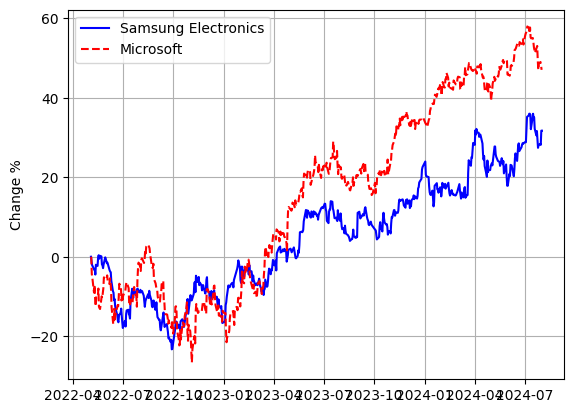

In [95]:
plt.plot(sec_data.index, sec_dpc_cs, 'b', label='Samsung Electronics')
plt.plot(msft_data.index, msft_dpc_cs, 'r--', label='Microsoft')
plt.ylabel('Change %')
plt.grid(True)
plt.legend(loc='best')
plt.show()

최대 손실 낙폭 (MDD)
KOSPI의 MDD 구하기

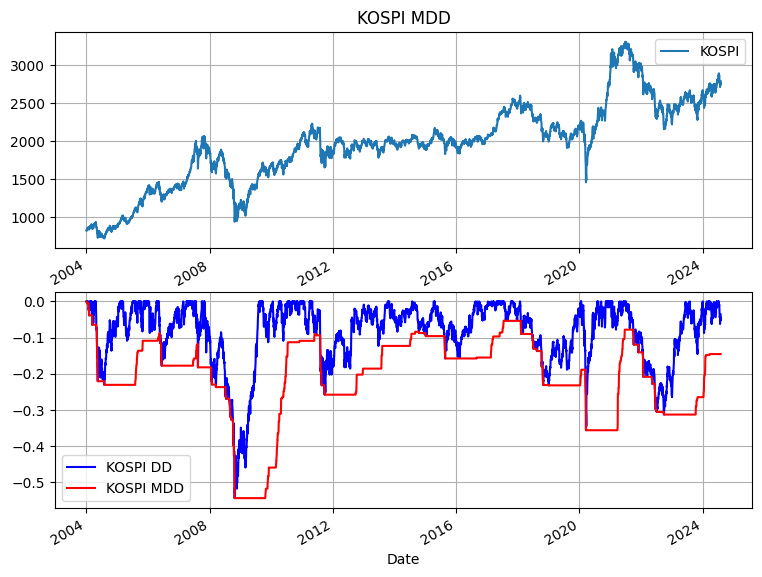

In [96]:
kospi = yf.Ticker('^KS11') # KOSPI 의 symbol
kospi_data = kospi.history(start="2004-01-04")

window = 252 # 산정 기간, 책에서는 1년동안 개정일을 252일로 어림잡았다.
peak = kospi_data['Close'].rolling(window, min_periods=1).max()
drawdown = kospi_data['Close']/peak - 1.0
max_dd = drawdown.rolling(window, min_periods=1).min()

plt.figure(figsize=(9,7))
plt.subplot(211) # 2행 1열 중 1행에 그린다.
kospi_data['Close'].plot(label='KOSPI', title='KOSPI MDD', grid=True, legend=True)
plt.subplot(212) # 2행 1열 중 2행에 그린다.
drawdown.plot(c='blue', label='KOSPI DD', grid=True, legend=True)
max_dd.plot(c='red', label='KOSPI MDD', grid=True, legend=True)
plt.show()

2008년 서브프라임 사태 때 MDD 가 최소이며 -54.5% 를 기록했다.

In [97]:
max_dd.min()

-0.5453665130144085

In [98]:
max_dd[max_dd==max_dd.min()]

Date
2008-10-24 00:00:00+09:00   -0.545367
2008-10-27 00:00:00+09:00   -0.545367
2008-10-28 00:00:00+09:00   -0.545367
2008-10-29 00:00:00+09:00   -0.545367
2008-10-30 00:00:00+09:00   -0.545367
                               ...   
2009-10-16 00:00:00+09:00   -0.545367
2009-10-19 00:00:00+09:00   -0.545367
2009-10-20 00:00:00+09:00   -0.545367
2009-10-21 00:00:00+09:00   -0.545367
2009-10-22 00:00:00+09:00   -0.545367
Name: Close, Length: 252, dtype: float64

KOSPI와 다우존스 지수 비교

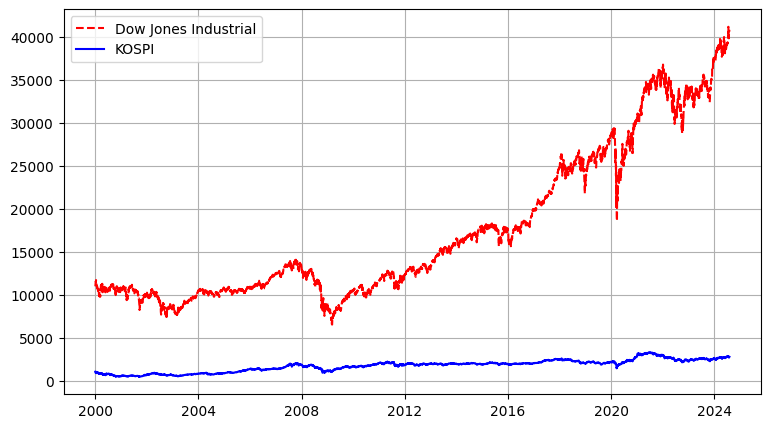

In [99]:
dow = yf.Ticker('^DJI')
dow_data = dow.history(start='2000-01-04')
kospi = yf.Ticker('^KS11')
kospi_data = kospi.history(start='2000-01-04')

plt.figure(figsize=(9,5))
plt.plot(dow_data.index, dow_data.Close, 'r--', label='Dow Jones Industrial')
plt.plot(kospi_data.index, kospi_data.Close, 'b', label='KOSPI')
plt.grid(True)
plt.legend(loc='best')
plt.show()

KOSPI 와 다우존스 지수로 비교

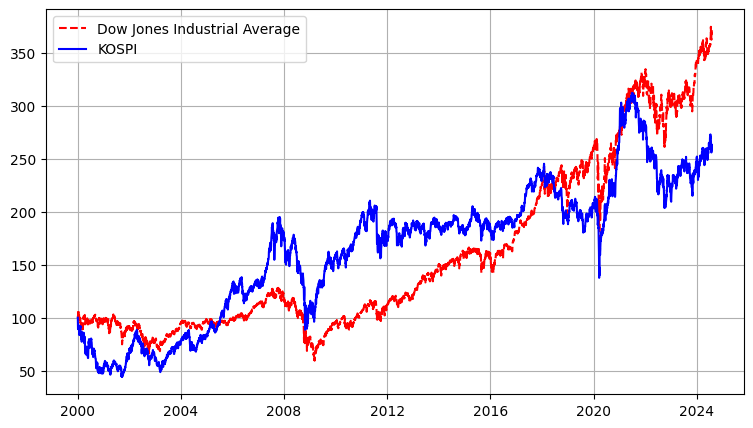

In [100]:
d = (dow_data.Close / dow_data.Close.loc['2000-01-04']) * 100
k = (kospi_data.Close / kospi_data.Close.loc['2000-01-04']) * 100

plt.figure(figsize=(9,5))
plt.plot(d.index, d, 'r--', label='Dow Jones Industrial Average')
plt.plot(k.index, k, 'b', label='KOSPI')
plt.grid(True)
plt.legend(loc='best')
plt.show()

산점도 분석

In [101]:
# KOSIP 의 데이터 개수와 다우존스 데이터 사이즈가 다르다. 같아지도록 전처리가 필요하다.
print(len(dow_data))
print(len(kospi_data))

df = pd.DataFrame(
    {
        'DOW': dow_data['Close'],
        'KOSPI': kospi_data['Close']
    }
)
# DataFrame 으로 선언을 하면 비어있는 index 에 대해서 자동으로 NaN 을 채워준다.

6182
6062


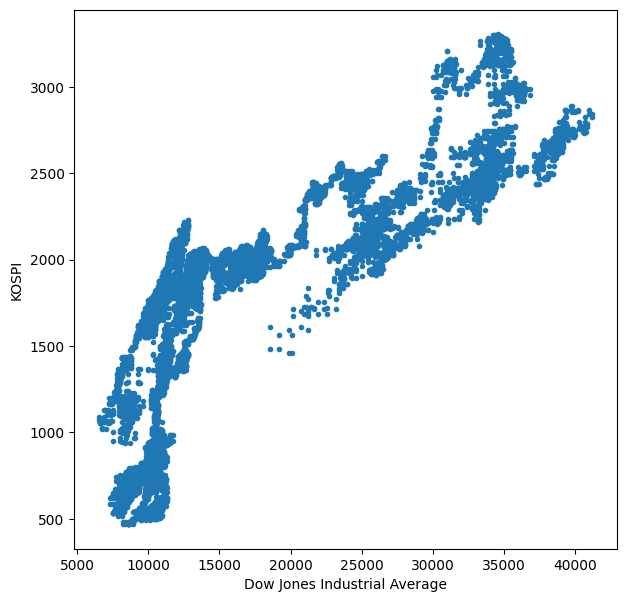

In [102]:
# (DEPRECATED) df = df.fillna(method='bfill') # backward fill (뒤에 값으로 NaN 을 채워주눈 방식)
df = df.bfill() # backward fill (뒤에 값으로 NaN 을 채워주눈 방식)
df = df.ffill() # forward fill (앞에 값으로 NaN 을 채워주눈 방식)
plt.figure(figsize=(7,7))
plt.scatter(df['DOW'], df['KOSPI'], marker='.')
plt.xlabel('Dow Jones Industrial Average')
plt.ylabel('KOSPI')
plt.show()

산점도 분석 결과 y = x 인 직선에 가까울 수록 직접적인 관계가 있음을 의미한다.

선형회귀

In [103]:
from scipy import stats
regr = stats.linregress(df.DOW, df.KOSPI)
print(regr) # rvalue 가 상관계수이다.

LinregressResult(slope=0.06349079993327358, intercept=634.2748066153003, rvalue=0.8264142329762778, pvalue=0.0, stderr=0.00039097007796044797, intercept_stderr=7.683973087658229)


# 상관계수 구하기 (Coefficienet of Correlartion)

두 지표간의 상관계수는 -1 ~ 1 사이의 값이다. 자산 A 와 자산 B 의 상관계수가 1이면 A 의 자산가치가 x% 증가할 때 B 도 x% 증가한다.

In [104]:
df.corr()

,DOW,KOSPI
DOW,1.000000,0.826414
KOSPI,0.826414,1.000000


In [105]:
df['DOW'].corr(df['KOSPI'])

0.8264142329762778

# 결정계수 구하기 (R-squared)

결정계수는 상관계수(R-value) 를 제곱한 값이다. 관계성이 얼마나 뚜렷한지 나타내는 척도이다. 0은 상관관계가 없으며, 1과 -1 은 상관관계가 뚜렸하다.

In [106]:
df['DOW'].corr(df['KOSPI']) ** 2

0.6829604844657696

KOSPI 와 다우존스 지수의 회귀분석

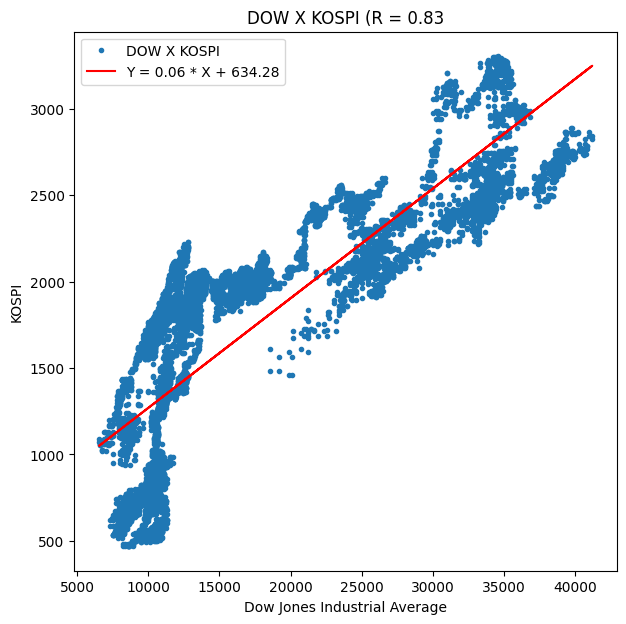

In [114]:
import pandas as pd
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt

dow_ticker = yf.Ticker('^DJI')
kospi_ticker = yf.Ticker('^KS11')

dow = dow_ticker.history(start='2000-01-04') 
kospi = kospi_ticker.history(start='2000-01-04') 

df = pd.DataFrame(
    {
        'X': dow['Close'],
        'Y': kospi['Close']
    }
)
df = df.bfill()
df = df.ffill()

regr = stats.linregress(df.X, df.Y)
regr_line = f'Y = {regr.slope:.2f} * X + {regr.intercept:.2f}'

plt.figure(figsize=(7,7))
plt.plot(df.X, df.Y, '.')
plt.plot(df.X, regr.slope * df.X + regr.intercept, 'r')
plt.legend(['DOW X KOSPI', regr_line])
plt.title(f'DOW X KOSPI (R = {regr.rvalue:.2f}')
plt.xlabel('Dow Jones Industrial Average')
plt.ylabel('KOSPI')
plt.show()

미국 국채와 KOSPI 회귀 분석
iShares 20 + Year Treasury Bond ETF (TLT)

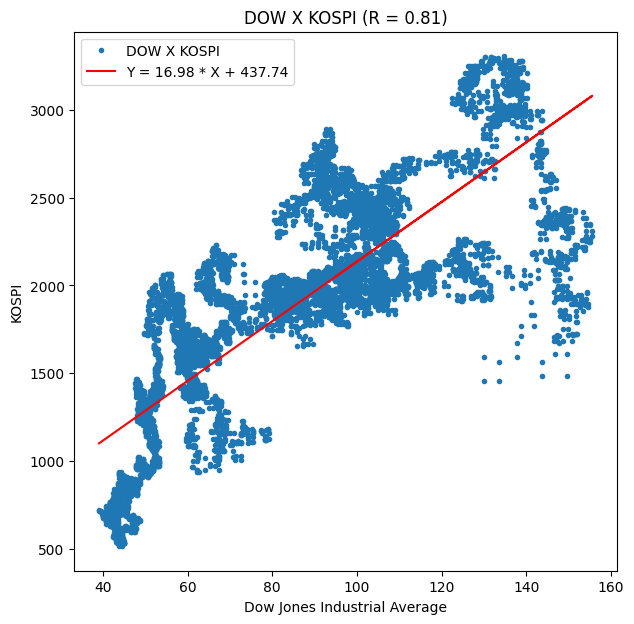

In [112]:
import pandas as pd
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt

dow_ticker = yf.Ticker('TLT')
kospi_ticker = yf.Ticker('^KS11')

dow = dow_ticker.history(start='2002-07-30') 
kospi = kospi_ticker.history(start='2002-07-30') 

df = pd.DataFrame(
    {
        'X': dow['Close'],
        'Y': kospi['Close']
    }
)
df = df.bfill()
df = df.ffill()

regr = stats.linregress(df.X, df.Y)
regr_line = f'Y = {regr.slope:.2f} * X + {regr.intercept:.2f}'

plt.figure(figsize=(7,7))
plt.plot(df.X, df.Y, '.')
plt.plot(df.X, regr.slope * df.X + regr.intercept, 'r')
plt.legend(['DOW X KOSPI', regr_line])
plt.title(f'DOW X KOSPI (R = {regr.rvalue:.2f})')
plt.xlabel('Dow Jones Industrial Average')
plt.ylabel('KOSPI')
plt.show()